In [1]:
import sys
import torch
import logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

current_dir = Path().resolve()
sys.path.append(str(current_dir.parent / "src"))

from hawkes import models, utils
from hawkes.utils import config, plotting

# NOTE: This example will be slow if a GPU is not available
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


# Parameters

In [2]:
# Parameters

# If running on CPU, consider reducing M and N
M = 100
N = 100000
T = float("inf")
batch_size = None  # If running out of memory, set to a power of 2 (e.g., 2^16=65536)

events_file = "outputs/data/events.pt"
model_sim_file = "outputs/data/model_sim.pt"
model_est_file = "outputs/data/model_est.pt"

# The fitting procedure prints to logger
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler()],
)
logger = logging.getLogger(__name__)

# Simulation

2026-04-13 16:45:57,304 - INFO - Starting simulation: t_start=0.0, t_end=inf
2026-04-13 16:48:07,444 - INFO - Simulated event sequence of length 100000 in [0, 1531.57]


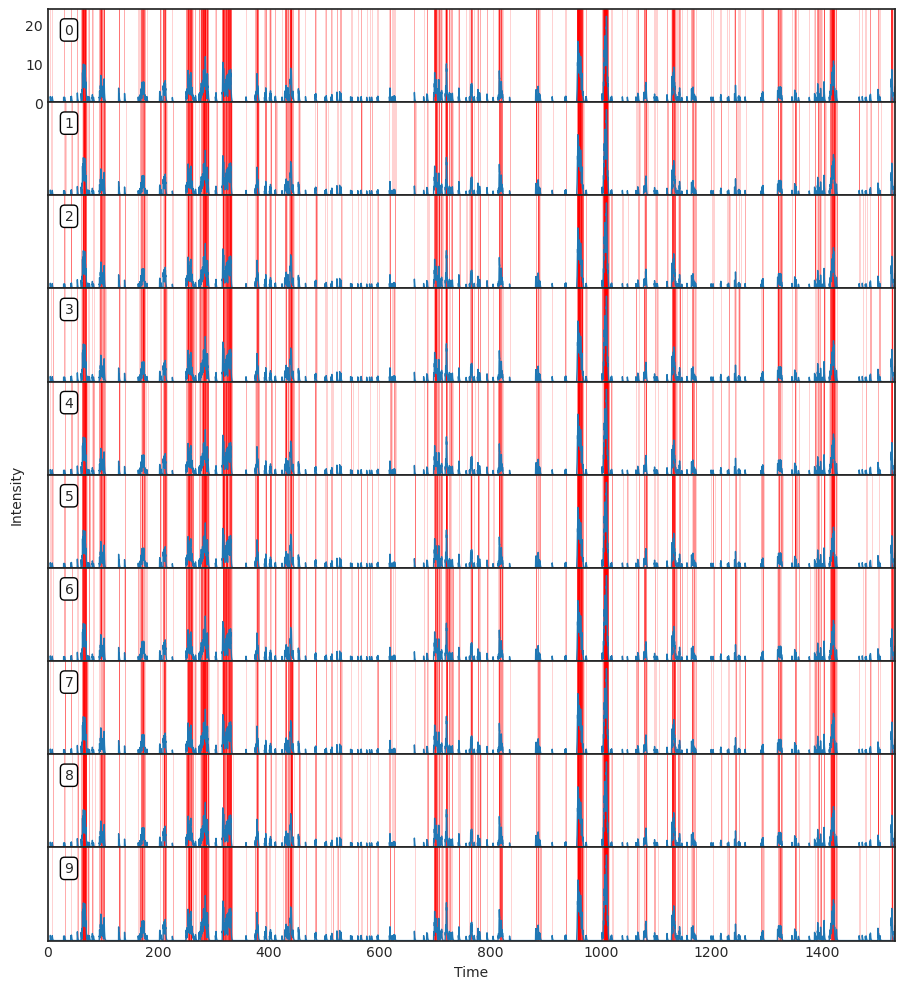

2026-04-13 16:48:13,958 - INFO - Saved event sequence to outputs/data/events.pt and simulation model to outputs/data/model_sim.pt


In [3]:
# Simulate simple hub-and-spoke interaction behavior

sim_mu = torch.zeros(M)
sim_mu[0] = 0.1  # Only hub has spontaneous events
sim_gamma = torch.tensor([1.5])
sim_alpha = torch.zeros(sim_gamma.shape[0], M, M)
sim_alpha[:, 0, :] = 0.9  # Hub influences all nodes including self

# Initialize model used for simulation
base_process = models.Poisson(M, mu_init=sim_mu)
model_sim = models.Hawkes(
    gamma=sim_gamma,
    gamma_param=False,
    base_process=base_process,
    alpha_init=sim_alpha,
)

# Simulate the event sequence
seq = model_sim.simulate(max_events=N)
logger.info(f"Simulated event sequence of length {seq.N} in [0, {seq.T:.2f}]")

# Plot first 10 dimensions of the intensity
plotting.plot_intensity(seq, model_sim, dimensions=list(range(10)))
plt.show()

# Save simulated event sequence and simulation model
torch.save(seq, events_file)
torch.save(model_sim, model_sim_file)
logger.info(
    f"Saved event sequence to {events_file} "
    f"and simulation model to {model_sim_file}"
)

# Estimation

2026-04-13 16:48:13,973 - INFO - Starting Hawkes process training: Hawkes with base process Poisson
2026-04-13 16:48:13,974 - INFO - Configuration: M=100, K=1, N=100,000, T=1,531.57, lr=0.1, steps=4000
2026-04-13 16:48:13,974 - INFO - Device: cuda:0, model params: 10,101
2026-04-13 16:48:21,148 - INFO - Starting training loop...
2026-04-13 16:48:29,331 - INFO - Epoch 400/4000: NLL=-0.2257, Sparsity=0.990, α_mean=0.0090, γ=[1.5], μ_mean=0.0014
2026-04-13 16:48:36,968 - INFO - Epoch 800/4000: NLL=-0.2258, Sparsity=0.990, α_mean=0.0090, γ=[1.5], μ_mean=0.0012
2026-04-13 16:48:44,599 - INFO - Epoch 1200/4000: NLL=-0.2259, Sparsity=0.990, α_mean=0.0090, γ=[1.5], μ_mean=0.0011
2026-04-13 16:48:52,233 - INFO - Epoch 1600/4000: NLL=-0.2259, Sparsity=0.990, α_mean=0.0090, γ=[1.5], μ_mean=0.0011
2026-04-13 16:48:59,867 - INFO - Epoch 2000/4000: NLL=-0.2259, Sparsity=0.990, α_mean=0.0090, γ=[1.5], μ_mean=0.0011
2026-04-13 16:49:07,501 - INFO - Epoch 2400/4000: NLL=-0.2259, Sparsity=0.990, α_mean=

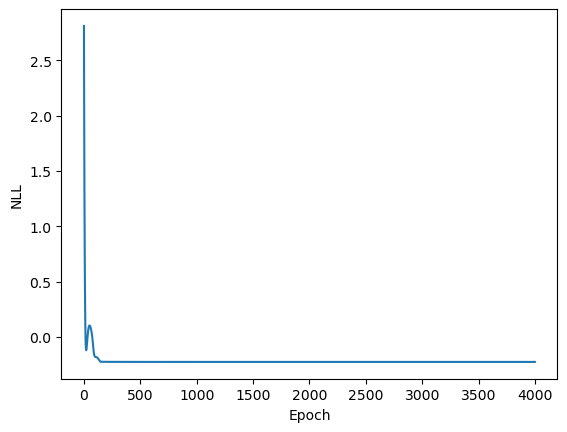

In [4]:
# Fit Hawkes process

est_gamma = torch.tensor([1.0])
fit_config = config.FitConfig(
    num_steps=4000,
    batch_size=batch_size,
    monitor_interval=400,
    learning_rate=0.1,
)

# Obtain event sequence and reference interaction matrix
seq = torch.load(events_file, weights_only=False).to(device)

# Sparsity penalty on interaction matrix
hawkes_penalty = models.HawkesPenalty(
    alpha=models.L1Penalty(weight=0.01, hinge=0.05),
)

# Constant base process
base_process = models.Poisson(M=seq.M)

# Can fit base process first if needed
# _ = base_process.fit(seq, None, None, fit_config)
# logger.info("Fitted base process")

# Fit estimation model
model_est = models.Hawkes(
    gamma=est_gamma,
    gamma_param=True,
    base_process=base_process,
    penalization=hawkes_penalty,
)

stats = model_est.fit(seq, fit_config)

# Save estimated model
torch.save(model_est, model_est_file)
logger.info(f"Saved estimated model to {model_est_file}")

# Plot training likelihood
plt.plot(np.arange(fit_config.num_steps), stats["nlls"])
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.show()

# Diagnostics

In [5]:
# Evaluate estimation performance

seq = torch.load("outputs/data/events.pt", weights_only=False)
model_sim = torch.load("outputs/data/model_sim.pt", weights_only=False)
model_est = torch.load("outputs/data/model_est.pt", weights_only=False)

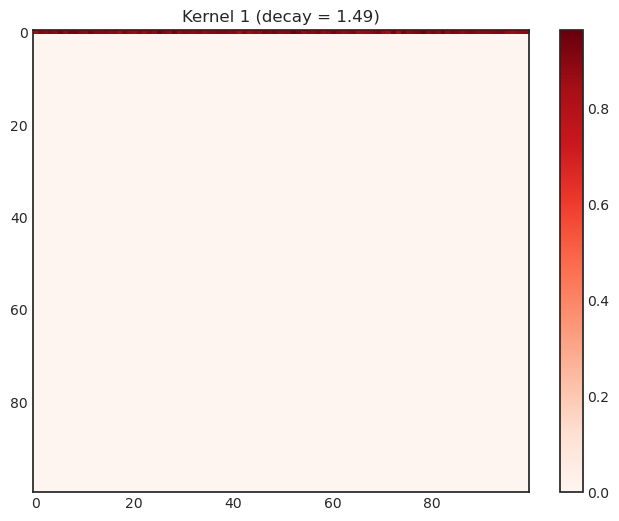

In [6]:
# Plot interaction matrices

fig, axes = plotting.plot_alpha(model_est.alpha.detach().cpu())

for k, ax in enumerate(axes.flatten()):
    ax.set_title(f"Kernel {k+1} (decay = {model_est.gamma[k].item():.2f})")

plt.show()

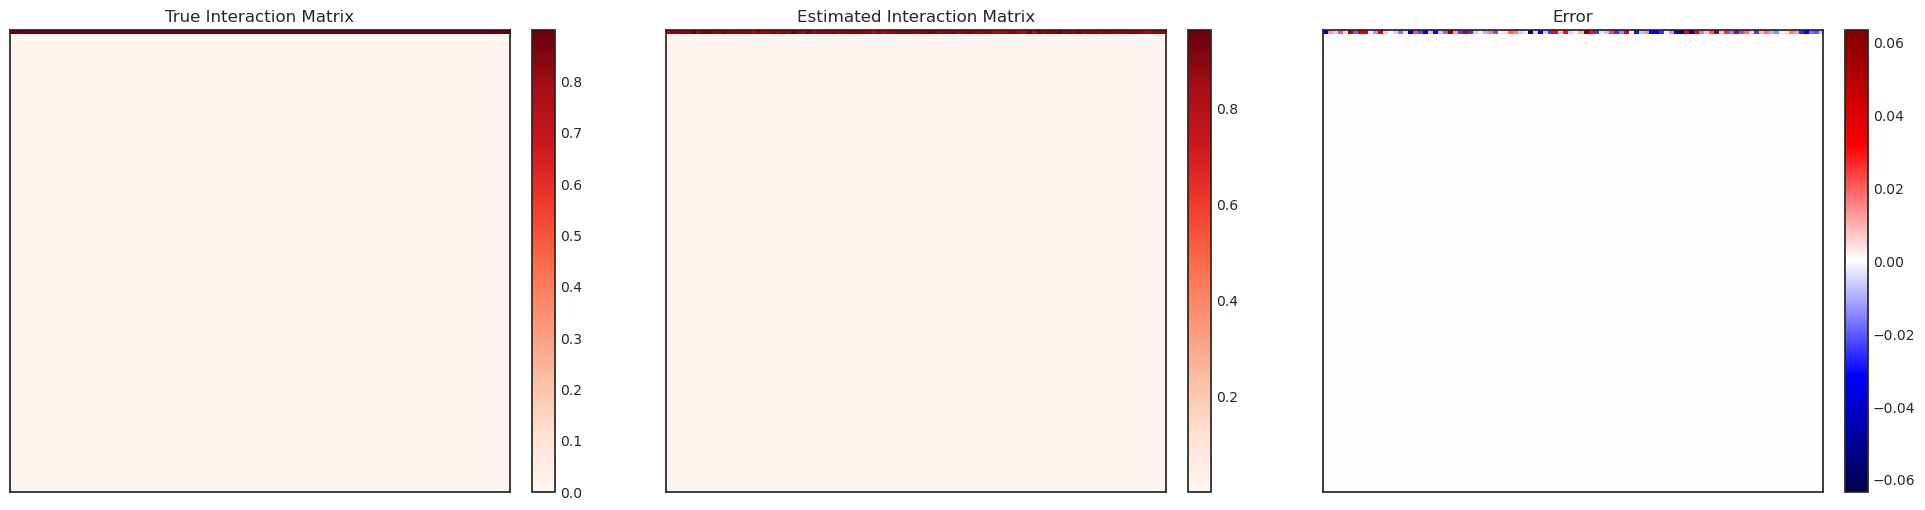

Rel. L2 error of mu: 7.003%
Rel. L2 error of alpha: 2.865%
Rel. L2 error of gamma: 0.748%


In [7]:
# Estimation performance of interaction matrix and excitation kernel

plotting.plot_alpha_comparison(
    true_alpha=model_sim.alpha.detach().cpu().sum(axis=0),
    estimated_alpha=model_est.alpha.detach().cpu().sum(axis=0),
)
plt.show()

rrmse = lambda true, est: ((true - est).square().sum() / true.square().sum()).sqrt()

# Assuming constant base process
true_mu = model_sim.base_process.mu(torch.zeros(1).to(device))
est_mu = model_est.base_process.mu(torch.zeros(1).to(device))

true_alpha = model_sim.alpha.detach().sum(dim=0).cpu()
est_alpha = model_est.alpha.detach().sum(dim=0).cpu()

print(f"Rel. L2 error of mu: {rrmse(true_mu, est_mu):.3%}")
print(f"Rel. L2 error of alpha: {rrmse(true_alpha, est_alpha):.3%}")
if model_est.gamma.shape[0] == 1:
    true_gamma = model_sim.gamma.detach().cpu()
    est_gamma = model_est.gamma.detach().cpu()
    print(f"Rel. L2 error of gamma: {rrmse(true_gamma, est_gamma):.3%}")

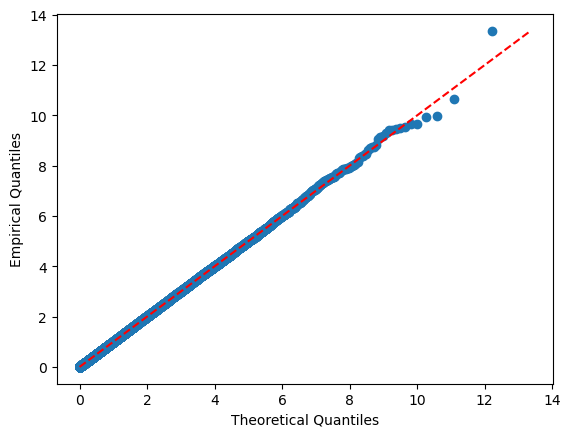

In [8]:
# Empirical quantiles versus theoretical Exp(1)

states = model_est.intensity_states(seq)
rescaled_times = model_est.rescaled_times(seq, states)
tau = rescaled_times.sum(dim=1).detach().cpu().numpy()
tau_sorted = np.sort(tau)

n = len(tau_sorted)
p = (np.arange(1, n + 1) - 0.5) / n

theoretical_quantiles = -np.log(1 - p)

plt.plot(theoretical_quantiles, tau_sorted, "o")
plt.plot(
    [0, max(theoretical_quantiles.max(), tau_sorted.max())],
    [0, max(theoretical_quantiles.max(), tau_sorted.max())],
    linestyle="--",
    color="red",
)

plt.xlabel("Theoretical Quantiles")
plt.ylabel("Empirical Quantiles")
plt.show()